In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import copy

In [7]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [8]:


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='../data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='../data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)
NUM_CLIENTS = 10

def split_noniid(dataset, num_clients, alpha=0.5):
    """
    Dirichlet-based non-IID split.
    For each class, sample a proportion vector from Dirichlet(alpha).
    That vector decides what fraction of that class goes to each client.
    """
    labels = np.array(dataset.targets)
    num_classes = 10
    client_indices = [[] for _ in range(num_clients)]

    for class_id in range(num_classes):
        # indices of all samples belonging to this class
        class_idx = np.where(labels == class_id)[0]
        np.random.shuffle(class_idx)

        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))

        
        proportions = (proportions * len(class_idx)).astype(int)

        
        proportions[-1] = len(class_idx) - proportions[:-1].sum()

    
        start = 0
        for client_id, count in enumerate(proportions):
            client_indices[client_id].extend(class_idx[start:start+count].tolist())
            start += count

    return [Subset(dataset, indices) for indices in client_indices]



client_datasets_iid    = split_noniid(train_dataset, NUM_CLIENTS, alpha=1000)  # effectively IID
client_datasets_noniid = split_noniid(train_dataset, NUM_CLIENTS, alpha=0.5)   # non-IID

test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print("Non-IID class distribution per client (alpha=0.5):\n")
labels = np.array(train_dataset.targets)
for i, subset in enumerate(client_datasets_noniid):
    client_labels = labels[subset.indices]
    counts = np.bincount(client_labels, minlength=10)
    dominant = counts.argmax()
    print(f"Client {i+1:2d} ({len(subset):5d} samples) — dominant digit: {dominant} | {counts}")

Non-IID class distribution per client (alpha=0.5):

Client  1 (  882 samples) — dominant digit: 1 | [  9 676 135   6   9   0  16  31   0   0]
Client  2 ( 9265 samples) — dominant digit: 2 | [ 429   33 3365  730   37  293 1599  155 1301 1323]
Client  3 (13703 samples) — dominant digit: 8 | [2044 1918  600  603 1931   17  317  736 4030 1507]
Client  4 ( 8435 samples) — dominant digit: 3 | [ 582   12  204 3587  295  588 2037  632   72  426]
Client  5 ( 4990 samples) — dominant digit: 7 | [ 382 1043    3    0  202  149  516 2112  441  142]
Client  6 ( 4102 samples) — dominant digit: 9 | [ 619    2    5  172  242    0   95  679    2 2286]
Client  7 ( 4405 samples) — dominant digit: 5 | [ 162    6   94  131  862 2402    8  729    0   11]
Client  8 ( 8295 samples) — dominant digit: 4 | [1289 1453  189  352 2186 1620   98 1004    0  104]
Client  9 ( 2277 samples) — dominant digit: 6 | [ 281  182  219    3   70  321 1070  130    1    0]
Client 10 ( 3646 samples) — dominant digit: 1 | [ 126 1417

C:\Users\HP\AppData\Local\Temp\ipykernel_10320\3570145687.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(dataset.targets)
C:\Users\HP\AppData\Local\Temp\ipykernel_10320\3570145687.py:50: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(train_dataset.targets)


In [9]:
class Client:
    def __init__(self, client_id, dataset, device, is_byzantine=False):
        self.client_id = client_id
        self.device = device
        self.is_byzantine = is_byzantine  # malicious flag
        self.loader = DataLoader(dataset, batch_size=32, shuffle=True)

    def train(self, global_weights, local_epochs=2):
        if self.is_byzantine:
            # Malicious client: return completely random weights
            # simulates a client that was hacked or is adversarial
            fake_model = MNISTNet().to(self.device)
            # randomize all weights — this poisons the aggregation
            for param in fake_model.parameters():
                nn.init.normal_(param.data, mean=0, std=10.0)
            print(f"  ⚠️  Client {self.client_id+1} sent poisoned weights!")
            return fake_model.state_dict()

        # Honest client: normal local training
        model = MNISTNet().to(self.device)
        model.load_state_dict(global_weights)
        model.train()
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
        criterion = nn.CrossEntropyLoss()

        for _ in range(local_epochs):
            for images, labels in self.loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(images), labels)
                loss.backward()
                optimizer.step()

        return model.state_dict()


class Server:
    def __init__(self, device, defense=None):
        self.device = device
        self.global_model = MNISTNet().to(device)
        self.defense = defense  # None = FedAvg, 'median' = Byzantine-robust

    def aggregate(self, client_weights):
        if self.defense == 'median':
            # Coordinate-wise median — outlier weights from Byzantine clients
            # get outvoted by the median of honest clients
            avg_weights = copy.deepcopy(client_weights[0])
            for key in avg_weights.keys():
                stacked = torch.stack(
                    [client_weights[i][key].float() for i in range(len(client_weights))], dim=0
                )
                avg_weights[key] = stacked.median(dim=0).values
        else:
            # Standard FedAvg — simple mean (vulnerable to attacks)
            avg_weights = copy.deepcopy(client_weights[0])
            for key in avg_weights.keys():
                avg_weights[key] = torch.stack(
                    [client_weights[i][key].float() for i in range(len(client_weights))], dim=0
                ).mean(dim=0)

        self.global_model.load_state_dict(avg_weights)

    def evaluate(self, test_loader):
        self.global_model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                predicted = self.global_model(images).argmax(dim=1)
                correct += (predicted == labels).sum().item()
        return correct / len(test_loader.dataset) * 100

    def get_weights(self):
        return copy.deepcopy(self.global_model.state_dict())

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_ROUNDS   = 5
LOCAL_EPOCHS = 2
NUM_CLIENTS  = 5

def run_experiment(client_datasets, device, num_rounds, local_epochs,
                   byzantine_ids=[], defense=None, label=""):
    """Run one full FL experiment and return accuracy per round."""
    server  = Server(device, defense=defense)
    clients = [
        Client(i, client_datasets[i], device, is_byzantine=(i in byzantine_ids))
        for i in range(NUM_CLIENTS)
    ]
    accuracies = []
    print(f"\n--- {label} ---")
    for r in range(1, num_rounds + 1):
        global_weights = server.get_weights()
        selected = np.random.choice(clients, NUM_CLIENTS, replace=False)
        client_weights = [c.train(global_weights, local_epochs) for c in selected]
        server.aggregate(client_weights)
        acc = server.evaluate(test_loader)
        accuracies.append(acc)
        print(f"Round {r:2d} — Accuracy: {acc:.2f}%")
    return accuracies

# Experiment 1: 
acc_iid = run_experiment(
    client_datasets_iid, device, NUM_ROUNDS, LOCAL_EPOCHS,
    label="IID — No Attack"
)

# Experiment 2: 
acc_noniid = run_experiment(
    client_datasets_noniid, device, NUM_ROUNDS, LOCAL_EPOCHS,
    label="Non-IID (α=0.5) — No Attack"
)

# Experiment 3: 
acc_attack = run_experiment(
    client_datasets_noniid, device, NUM_ROUNDS, LOCAL_EPOCHS,
    byzantine_ids=[0, 1],  # clients 1 and 2 are malicious
    defense=None,
    label="Non-IID — 2 Byzantine Attackers (No Defense)"
)

# Experiment 4: 
acc_defense = run_experiment(
    client_datasets_noniid, device, NUM_ROUNDS, LOCAL_EPOCHS,
    byzantine_ids=[0, 1],
    defense='median',
    label="Non-IID — 2 Byzantine Attackers (Median Defense)"
)


--- IID — No Attack ---
Round  1 — Accuracy: 96.88%
Round  2 — Accuracy: 98.16%
Round  3 — Accuracy: 98.55%
Round  4 — Accuracy: 98.64%
Round  5 — Accuracy: 98.79%

--- Non-IID (α=0.5) — No Attack ---
Round  1 — Accuracy: 91.85%
Round  2 — Accuracy: 97.61%
Round  3 — Accuracy: 98.36%
Round  4 — Accuracy: 98.57%
Round  5 — Accuracy: 98.79%

--- Non-IID — 2 Byzantine Attackers (No Defense) ---
  ⚠️  Client 1 sent poisoned weights!
  ⚠️  Client 2 sent poisoned weights!
Round  1 — Accuracy: 10.93%
  ⚠️  Client 1 sent poisoned weights!
  ⚠️  Client 2 sent poisoned weights!
Round  2 — Accuracy: 9.80%
  ⚠️  Client 2 sent poisoned weights!
  ⚠️  Client 1 sent poisoned weights!
Round  3 — Accuracy: 9.80%
  ⚠️  Client 1 sent poisoned weights!
  ⚠️  Client 2 sent poisoned weights!
Round  4 — Accuracy: 9.80%
  ⚠️  Client 2 sent poisoned weights!
  ⚠️  Client 1 sent poisoned weights!
Round  5 — Accuracy: 9.80%

--- Non-IID — 2 Byzantine Attackers (Median Defense) ---
  ⚠️  Client 2 sent poisoned w

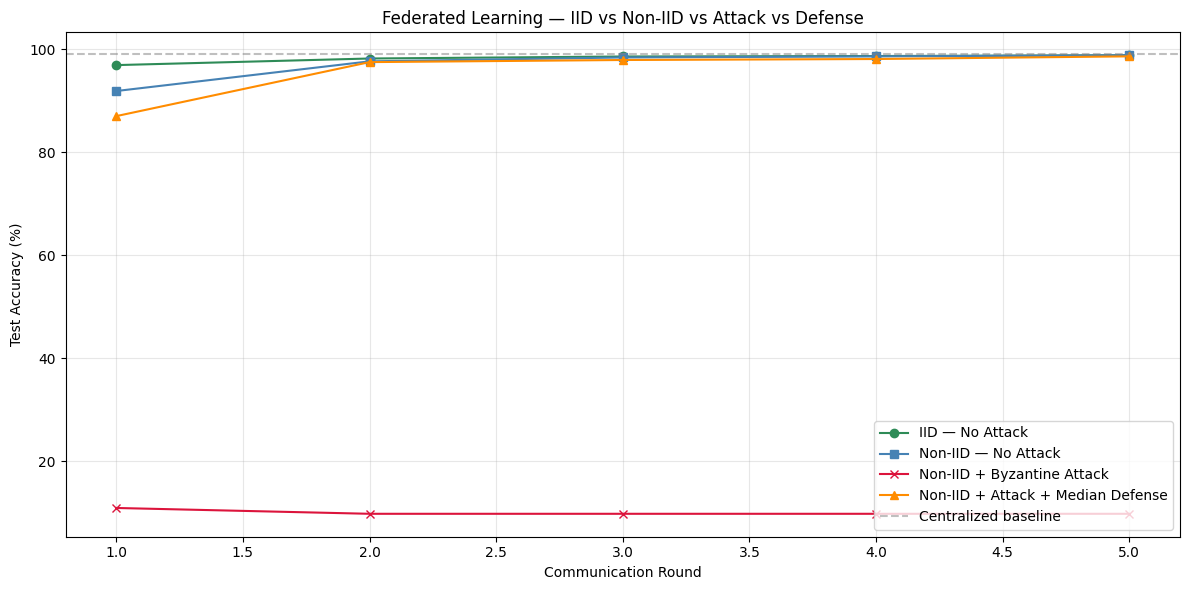

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(range(1, NUM_ROUNDS+1), acc_iid,     marker='o', color='seagreen',   label='IID — No Attack')
plt.plot(range(1, NUM_ROUNDS+1), acc_noniid,  marker='s', color='steelblue',  label='Non-IID — No Attack')
plt.plot(range(1, NUM_ROUNDS+1), acc_attack,  marker='x', color='crimson',    label='Non-IID + Byzantine Attack')
plt.plot(range(1, NUM_ROUNDS+1), acc_defense, marker='^', color='darkorange',  label='Non-IID + Attack + Median Defense')

plt.axhline(y=99.1, color='gray', linestyle='--', alpha=0.5, label='Centralized baseline')

plt.title('Federated Learning — IID vs Non-IID vs Attack vs Defense')
plt.xlabel('Communication Round')
plt.ylabel('Test Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/phase3_comparison.png', dpi=150)
plt.show()